# Text Classification with OpenAI Embeddings + PCA

This notebook implements a minimal sklearn-style binary text classification pipeline:

1. Load text dataset (`text`, `label`)
2. Split data 75/25 (train/test)
3. Generate OpenAI embeddings
4. Reduce dimensions with PCA
5. Train Logistic Regression classifier
6. Evaluate with metrics and visualizations


## Setup

- Download UCI SMS Spam dataset file (`SMSSpamCollection`) and set `RAW_DATA_PATH` below.

In [12]:
from __future__ import annotations

import hashlib
import json
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
from openai import OpenAI
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt


In [ ]:
RAW_DATA_PATH = Path("SMSSpamCollection")  # update if needed
CACHE_PATH = Path(".embedding_cache_sms.json")
EMBEDDING_MODEL = "text-embedding-3-small"
TEST_SIZE = 0.25
RANDOM_STATE = 42
PCA_COMPONENTS = 100
BATCH_SIZE = 64

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset file not found: {RAW_DATA_PATH}")

# UCI format: label\ttext
df = pd.read_csv(RAW_DATA_PATH, sep="\t", header=None, names=["raw_label", "text"])
df["label"] = (df["raw_label"].str.lower() == "spam").astype(int)
df = df[["text", "label"]].dropna().copy()

print(df.head())
print("\nClass counts:\n", df["label"].value_counts())
print("Total samples:", len(df))


                                                text  label
0  Go until jurong point, crazy.. Available only ...      0
1                      Ok lar... Joking wif u oni...      0
2  Free entry in 2 a wkly comp to win FA Cup fina...      1
3  U dun say so early hor... U c already then say...      0
4  Nah I don't think he goes to usf, he lives aro...      0

Class counts:
 label
0    4825
1     747
Name: count, dtype: int64
Total samples: 5572


In [14]:
def text_key(text: str, model: str) -> str:
    return hashlib.sha256(f"{model}::{text}".encode("utf-8")).hexdigest()


def chunked(items: list[str], size: int) -> Iterable[list[str]]:
    for i in range(0, len(items), size):
        yield items[i : i + size]


def load_cache(path: Path) -> dict[str, list[float]]:
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding="utf-8"))


def save_cache(path: Path, cache: dict[str, list[float]]) -> None:
    path.write_text(json.dumps(cache), encoding="utf-8")


def embed_texts(client: OpenAI, texts: list[str], model: str, batch_size: int, cache_path: Path) -> np.ndarray:
    cache = load_cache(cache_path)
    missing = [t for t in texts if text_key(t, model) not in cache]

    for batch in chunked(missing, batch_size):
        response = client.embeddings.create(model=model, input=batch)
        for text, item in zip(batch, response.data):
            cache[text_key(text, model)] = item.embedding

    if missing:
        save_cache(cache_path, cache)

    vectors = [cache[text_key(t, model)] for t in texts]
    return np.array(vectors, dtype=np.float32)


In [15]:
x_train_text, x_test_text, y_train, y_test = train_test_split(
    df["text"].tolist(),
    df["label"].to_numpy(),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["label"].to_numpy(),
)

print("Train size:", len(x_train_text))
print("Test size:", len(x_test_text))


Train size: 4179
Test size: 1393


In [16]:
client = OpenAI()  # uses OPENAI_API_KEY from environment

x_train_embed = embed_texts(client, x_train_text, EMBEDDING_MODEL, BATCH_SIZE, CACHE_PATH)
x_test_embed = embed_texts(client, x_test_text, EMBEDDING_MODEL, BATCH_SIZE, CACHE_PATH)

max_components = min(x_train_embed.shape[1], x_train_embed.shape[0] - 1)
n_components = min(PCA_COMPONENTS, max_components)
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
x_train_reduced = pca.fit_transform(x_train_embed)
x_test_reduced = pca.transform(x_test_embed)

clf = LogisticRegression(max_iter=1000)
clf.fit(x_train_reduced, y_train)
y_pred = clf.predict(x_test_reduced)
y_prob = clf.predict_proba(x_test_reduced)[:, 1]

print("Embedding shape (train):", x_train_embed.shape)
print("PCA components used:", n_components)
print("Explained variance ratio sum:", round(float(pca.explained_variance_ratio_.sum()), 4))


Embedding shape (train): (4179, 1536)
PCA components used: 100
Explained variance ratio sum: 0.5667


In [17]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy : 0.9907
Precision: 0.9943
Recall   : 0.9358
F1-score : 0.9642
ROC-AUC  : 0.9978

Classification report:

              precision    recall  f1-score   support

           0     0.9901    0.9992    0.9946      1206
           1     0.9943    0.9358    0.9642       187

    accuracy                         0.9907      1393
   macro avg     0.9922    0.9675    0.9794      1393
weighted avg     0.9907    0.9907    0.9905      1393

Confusion matrix:
 [[1205    1]
 [  12  175]]


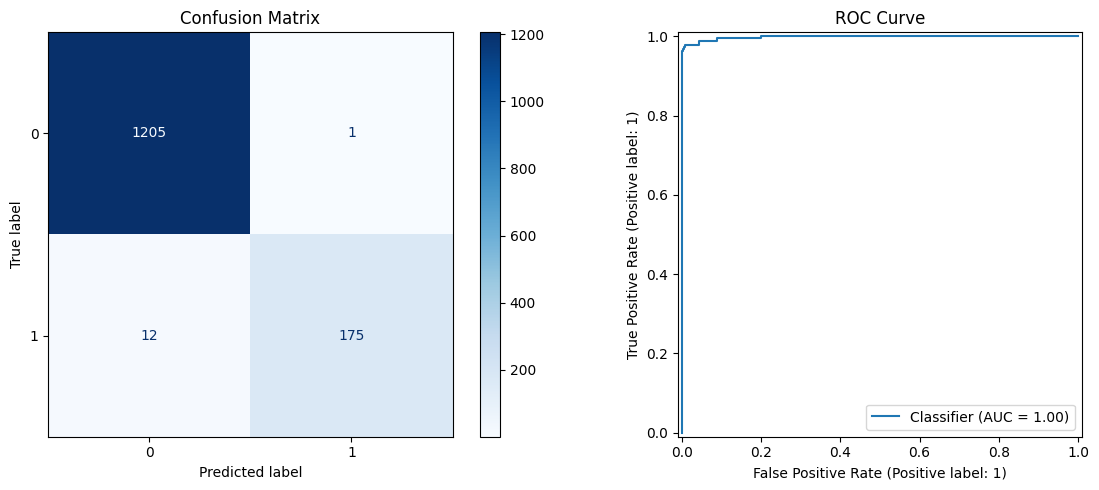

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()


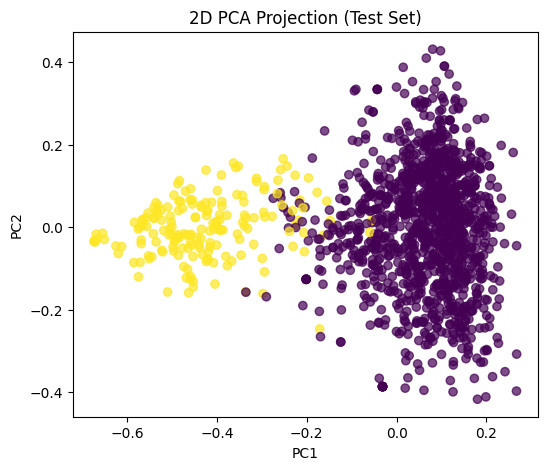

In [19]:
# Optional: 2D PCA visualization of test embeddings
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
x_test_2d = pca_2d.fit_transform(x_test_embed)

plt.figure(figsize=(6, 5))
plt.scatter(x_test_2d[:, 0], x_test_2d[:, 1], c=y_test, alpha=0.7)
plt.title("2D PCA Projection (Test Set)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
